# TIFF Compression Results Analysis

This notebook downloads and analyzes the results from the TIFF compression experiments logged to wandb. It groups results by experiment prefix and creates comparison plots for different quality metrics.

## Features:
- Downloads experiment data from wandb
- Groups results by experiment name prefix (everything before the last underscore)
- Creates plots comparing:
  - CQ_HW vs PSNR
  - Compression Ratio vs PSNR
  - CQ_HW vs SSIM
  - Compression Ratio vs SSIM

## Import Required Libraries

Import necessary libraries including wandb, pandas, matplotlib, seaborn, and numpy for data analysis and visualization.

In [3]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Optional
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("✅ Libraries imported successfully!")
print("Available plotting styles:")
print("- matplotlib with seaborn color palette")
print("- Grid enabled for better readability")
print("- Default figure size: 12x8 inches")

✅ Libraries imported successfully!
Available plotting styles:
- matplotlib with seaborn color palette
- Grid enabled for better readability
- Default figure size: 12x8 inches


## Initialize WandB Client and Download Results

Set up WandB API client and download all runs from the tiff-compression-sweep-test project.

In [5]:
# Initialize wandb API
api = wandb.Api()

# Project configuration
WANDB_PROJECT = "tiff-compression-sweep"  # Change this to your actual project name
WANDB_ENTITY = None  # Set to your wandb entity if needed

print(f"🔄 Connecting to WandB project: {WANDB_PROJECT}")

try:
    # Download runs from the project
    if WANDB_ENTITY:
        project_path = f"{WANDB_ENTITY}/{WANDB_PROJECT}"
    else:
        project_path = WANDB_PROJECT
        
    runs = api.runs(project_path)
    print(f"✅ Connected successfully!")
    print(f"📊 Found {len(runs)} runs in the project")
    
    if len(runs) == 0:
        print("⚠️  No runs found. Make sure you've run the compression sweep script first.")
    else:
        print("\n🔍 Preview of available runs:")
        for i, run in enumerate(runs[:5]):  # Show first 5 runs
            print(f"  {i+1}. {run.name} - State: {run.state}")
        if len(runs) > 5:
            print(f"  ... and {len(runs) - 5} more runs")
            
except Exception as e:
    print(f"❌ Error connecting to WandB: {e}")
    print("Make sure you're logged in to wandb (run 'wandb login' in terminal)")
    runs = []

🔄 Connecting to WandB project: tiff-compression-sweep
✅ Connected successfully!
✅ Connected successfully!
📊 Found 96 runs in the project

🔍 Preview of available runs:
  1. ca76a1e9-f409-493e-9446-b758e100ce63_0_2020-05-26-_cq100 - State: finished
  2. ca76a1e9-f409-493e-9446-b758e100ce63_0_2020-05-26-_cq98 - State: finished
  3. ca76a1e9-f409-493e-9446-b758e100ce63_0_2020-05-26-_cq96 - State: finished
  4. ca76a1e9-f409-493e-9446-b758e100ce63_0_2020-05-26-_cq94 - State: finished
  5. ca76a1e9-f409-493e-9446-b758e100ce63_0_2020-05-26-_cq92 - State: finished
  ... and 91 more runs
📊 Found 96 runs in the project

🔍 Preview of available runs:
  1. ca76a1e9-f409-493e-9446-b758e100ce63_0_2020-05-26-_cq100 - State: finished
  2. ca76a1e9-f409-493e-9446-b758e100ce63_0_2020-05-26-_cq98 - State: finished
  3. ca76a1e9-f409-493e-9446-b758e100ce63_0_2020-05-26-_cq96 - State: finished
  4. ca76a1e9-f409-493e-9446-b758e100ce63_0_2020-05-26-_cq94 - State: finished
  5. ca76a1e9-f409-493e-9446-b758e10

## Process and Group Experiment Data

Extract experiment data from WandB runs and group them by experiment name prefix (everything before the last underscore).

In [6]:
def extract_experiment_prefix(experiment_name: str) -> str:
    """
    Extract the experiment prefix (everything up to the last underscore).
    
    Args:
        experiment_name: Full experiment name (e.g., "dataset1_cq100")
        
    Returns:
        Experiment prefix (e.g., "dataset1")
    """
    if '_' not in experiment_name:
        return experiment_name
    
    parts = experiment_name.split('_')
    return '_'.join(parts[:-1])

def process_wandb_runs(runs) -> pd.DataFrame:
    """
    Process WandB runs and extract relevant metrics into a pandas DataFrame.
    
    Args:
        runs: List of WandB run objects
        
    Returns:
        DataFrame with processed experiment data
    """
    data = []
    
    print("🔄 Processing runs and extracting data...")
    
    for i, run in enumerate(runs):
        try:
            # Extract experiment name and prefix
            experiment_name = run.name
            experiment_prefix = extract_experiment_prefix(experiment_name)
            
            # Extract metrics from run summary
            summary = run.summary
            config = run.config
            
            # Get key metrics (with default values if missing)
            run_data = {
                'experiment_name': experiment_name,
                'experiment_prefix': experiment_prefix,
                'run_id': run.id,
                'state': run.state,
                'cq_hw': config.get('cq_hw', summary.get('CQ_HW', None)),
                'psnr': summary.get('PSNR (dB)', None),
                'ssim': summary.get('SSIM', None),
                'compression_ratio': summary.get('Compression Ratio', None),
                'space_savings': summary.get('Space Savings (%)', None),
                'original_size_mb': summary.get('Original Size (MB)', None),
                'compressed_size_mb': summary.get('Compressed Size (MB)', None),
                'bits_per_pixel_original': summary.get('Bits/Pixel Original', None),
                'bits_per_pixel_compressed': summary.get('Bits/Pixel Compressed', None),
                'mse': summary.get('MSE', None),
                'compute_time': summary.get('Compute Time (s)', None),
                'fps': config.get('fps', summary.get('FPS', None)),
                'frames_analyzed': summary.get('Frames Analyzed', None),
                'skip_frames': config.get('skip_frames', summary.get('Skip Frames', None))
            }
            
            data.append(run_data)
            
            if (i + 1) % 10 == 0:
                print(f"  Processed {i + 1}/{len(runs)} runs...")
                
        except Exception as e:
            print(f"⚠️  Error processing run {run.name}: {e}")
            continue
    
    df = pd.DataFrame(data)
    print(f"✅ Successfully processed {len(df)} runs")
    
    return df

# Process the runs
if runs:
    df_results = process_wandb_runs(runs)
    
    # Display basic statistics
    print(f"\n📊 Data Summary:")
    print(f"  Total experiments: {len(df_results)}")
    print(f"  Unique experiment prefixes: {df_results['experiment_prefix'].nunique()}")
    print(f"  CQ_HW values range: {df_results['cq_hw'].min()} - {df_results['cq_hw'].max()}")
    print(f"  Successful runs: {(df_results['state'] == 'finished').sum()}")
    
    print(f"\n🏷️  Experiment prefixes found:")
    prefix_counts = df_results['experiment_prefix'].value_counts()
    for prefix, count in prefix_counts.items():
        print(f"  - {prefix}: {count} experiments")
        
    # Show first few rows
    print(f"\n📋 Sample data:")
    display_cols = ['experiment_prefix', 'cq_hw', 'psnr', 'ssim', 'compression_ratio', 'state']
    print(df_results[display_cols].head())
    
else:
    print("❌ No runs to process")
    df_results = pd.DataFrame()

🔄 Processing runs and extracting data...
  Processed 10/96 runs...
  Processed 20/96 runs...
  Processed 30/96 runs...
  Processed 40/96 runs...
  Processed 50/96 runs...
  Processed 60/96 runs...
  Processed 70/96 runs...
  Processed 80/96 runs...
  Processed 90/96 runs...
✅ Successfully processed 96 runs

📊 Data Summary:
  Total experiments: 96
  Unique experiment prefixes: 12
  CQ_HW values range: 80 - 100
  Successful runs: 96

🏷️  Experiment prefixes found:
  - ca76a1e9-f409-493e-9446-b758e100ce63_0_2020-05-26-: 8 experiments
  - da8dae01-7e51-4b77-afa8-71ab6879c917_0_2020-05-26-: 8 experiments
  - 76db6207-ee3f-4329-b541-3a9dd4e93af2_0_2020-05-26-: 8 experiments
  - 3a02cbef-042d-4d7e-8f9f-ad964a3bfde3_0_2020-05-26-: 8 experiments
  - deb3d13d-f3f2-4a1b-8de6-696a5ed7ee62_0_2020-05-26-: 8 experiments
  - 9859a11a-1394-4413-b7bf-871b31095a41_0_2020-05-26-: 8 experiments
  - 7cf4bba4-403b-48dd-a8c7-deb5ea13e6bc_0_2020-05-26-: 8 experiments
  - fd96f0bb-171b-4644-81e4-1cf2775cefc9_0_

## Calculate Metrics and Group by Experiment Prefix

Process the downloaded data to extract CQ_HW values, PSNR, SSIM, and compression ratios, then group by experiment prefix.

In [7]:
def prepare_data_for_plotting(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean and prepare data for plotting by filtering successful runs and handling missing values.
    
    Args:
        df: Raw DataFrame from WandB runs
        
    Returns:
        Cleaned DataFrame ready for plotting
    """
    # Filter for successful runs only
    df_clean = df[df['state'] == 'finished'].copy()
    
    # Remove rows with missing critical metrics
    critical_cols = ['cq_hw', 'psnr', 'ssim', 'compression_ratio']
    df_clean = df_clean.dropna(subset=critical_cols)
    
    # Convert data types
    numeric_cols = ['cq_hw', 'psnr', 'ssim', 'compression_ratio', 'space_savings', 
                   'original_size_mb', 'compressed_size_mb', 'bits_per_pixel_original',
                   'bits_per_pixel_compressed', 'mse', 'compute_time']
    
    for col in numeric_cols:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    # Sort by experiment prefix and cq_hw for better plotting
    df_clean = df_clean.sort_values(['experiment_prefix', 'cq_hw'])
    
    return df_clean

if not df_results.empty:
    # Clean and prepare data
    df_plot = prepare_data_for_plotting(df_results)
    
    print(f"📊 Data preparation complete:")
    print(f"  Cleaned dataset size: {len(df_plot)} runs")
    print(f"  Experiment prefixes: {df_plot['experiment_prefix'].nunique()}")
    print(f"  CQ_HW values: {sorted(df_plot['cq_hw'].unique())}")
    
    # Group data by experiment prefix for analysis
    grouped_data = df_plot.groupby('experiment_prefix')
    
    print(f"\n📈 Data ranges by metric:")
    metrics_info = {
        'PSNR (dB)': df_plot['psnr'],
        'SSIM': df_plot['ssim'],
        'Compression Ratio': df_plot['compression_ratio'],
        'CQ_HW': df_plot['cq_hw']
    }
    
    for metric_name, values in metrics_info.items():
        print(f"  {metric_name}: {values.min():.3f} - {values.max():.3f}")
    
    # Show data distribution by experiment prefix
    print(f"\n🔍 Data points per experiment prefix:")
    for prefix, group in grouped_data:
        cq_values = sorted(group['cq_hw'].unique())
        print(f"  {prefix}: {len(group)} runs, CQ values: {cq_values}")
        
else:
    print("❌ No data available for plotting")
    df_plot = pd.DataFrame()

📊 Data preparation complete:
  Cleaned dataset size: 96 runs
  Experiment prefixes: 12
  CQ_HW values: [np.int64(80), np.int64(85), np.int64(90), np.int64(92), np.int64(94), np.int64(96), np.int64(98), np.int64(100)]

📈 Data ranges by metric:
  PSNR (dB): 39.521 - 69.669
  SSIM: 0.929 - 1.000
  Compression Ratio: 2.072 - 267.899
  CQ_HW: 80.000 - 100.000

🔍 Data points per experiment prefix:
  18f3f7df-fbbd-48cc-82d5-54e3da604303_0_2020-05-26-: 8 runs, CQ values: [np.int64(80), np.int64(85), np.int64(90), np.int64(92), np.int64(94), np.int64(96), np.int64(98), np.int64(100)]
  3a02cbef-042d-4d7e-8f9f-ad964a3bfde3_0_2020-05-26-: 8 runs, CQ values: [np.int64(80), np.int64(85), np.int64(90), np.int64(92), np.int64(94), np.int64(96), np.int64(98), np.int64(100)]
  5d9f8e87-029c-400d-8f88-667b9cf4afcd_0_2020-05-26-: 8 runs, CQ values: [np.int64(80), np.int64(85), np.int64(90), np.int64(92), np.int64(94), np.int64(96), np.int64(98), np.int64(100)]
  76db6207-ee3f-4329-b541-3a9dd4e93af2_0_202

## Plot CQ_HW vs PSNR

Create line plots showing the relationship between CQ_HW values and PSNR metrics, with separate lines for each experiment group.

📊 Creating CQ_HW vs PSNR plot...


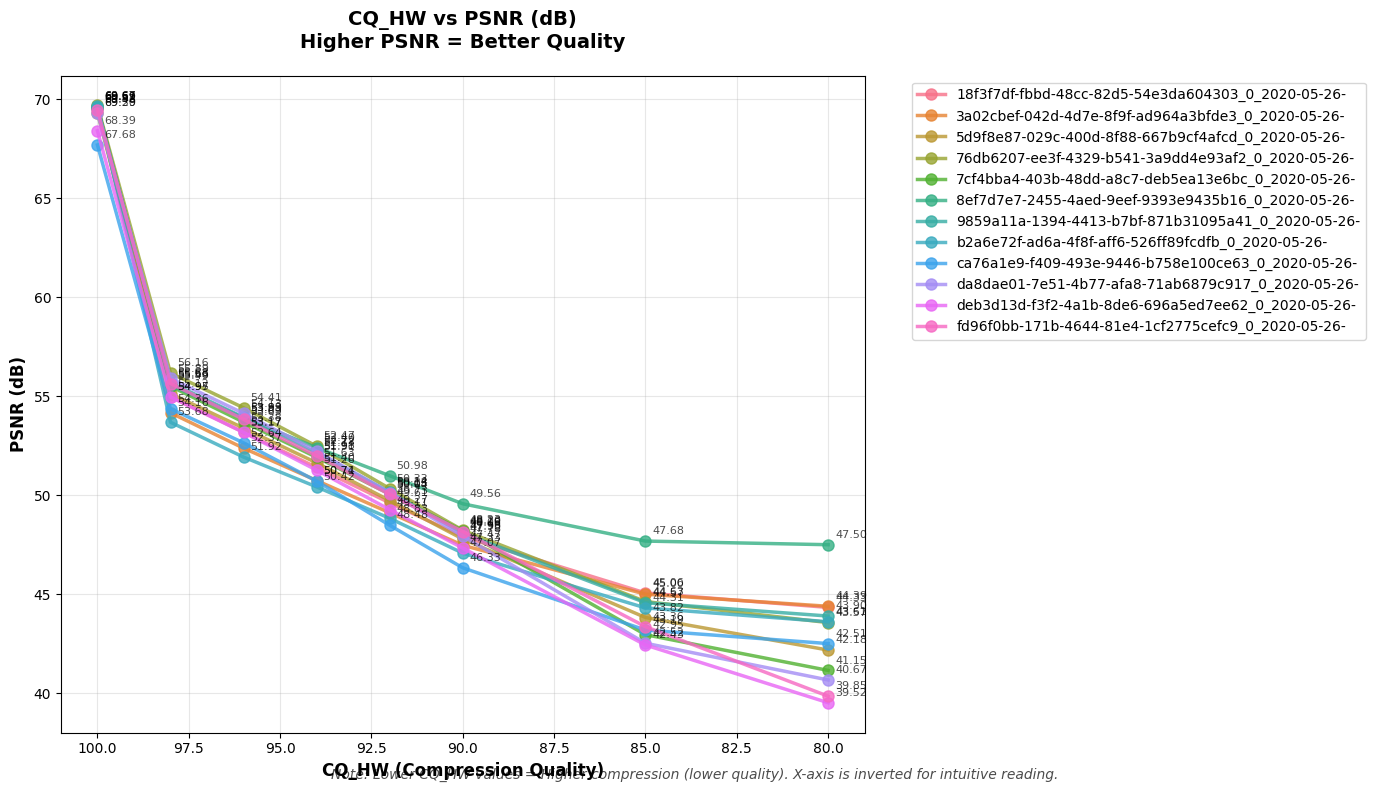


📈 PSNR Analysis:
  18f3f7df-fbbd-48cc-82d5-54e3da604303_0_2020-05-26-: PSNR range = 25.26 dB (from 44.33 to 69.59)
  3a02cbef-042d-4d7e-8f9f-ad964a3bfde3_0_2020-05-26-: PSNR range = 25.22 dB (from 44.39 to 69.61)
  5d9f8e87-029c-400d-8f88-667b9cf4afcd_0_2020-05-26-: PSNR range = 27.12 dB (from 42.18 to 69.30)
  76db6207-ee3f-4329-b541-3a9dd4e93af2_0_2020-05-26-: PSNR range = 26.10 dB (from 43.57 to 69.67)
  7cf4bba4-403b-48dd-a8c7-deb5ea13e6bc_0_2020-05-26-: PSNR range = 28.44 dB (from 41.15 to 69.59)
  8ef7d7e7-2455-4aed-9eef-9393e9435b16_0_2020-05-26-: PSNR range = 22.03 dB (from 47.50 to 69.53)
  9859a11a-1394-4413-b7bf-871b31095a41_0_2020-05-26-: PSNR range = 25.62 dB (from 43.90 to 69.52)
  b2a6e72f-ad6a-4f8f-aff6-526ff89fcdfb_0_2020-05-26-: PSNR range = 26.06 dB (from 43.61 to 69.67)
  ca76a1e9-f409-493e-9446-b758e100ce63_0_2020-05-26-: PSNR range = 25.17 dB (from 42.51 to 67.68)
  da8dae01-7e51-4b77-afa8-71ab6879c917_0_2020-05-26-: PSNR range = 28.62 dB (from 40.67 to 69.29)
  

In [8]:
def plot_cq_vs_metric(df: pd.DataFrame, metric_col: str, metric_name: str, 
                     title_suffix: str = "", figsize: tuple = (14, 8)):
    """
    Create a line plot of CQ_HW vs a specified metric, grouped by experiment prefix.
    
    Args:
        df: DataFrame with experiment data
        metric_col: Column name for the y-axis metric
        metric_name: Display name for the metric
        title_suffix: Additional text for the title
        figsize: Figure size tuple
    """
    if df.empty:
        print(f"❌ No data available for {metric_name} plot")
        return
    
    plt.figure(figsize=figsize)
    
    # Get unique experiment prefixes and create color palette
    prefixes = sorted(df['experiment_prefix'].unique())
    colors = sns.color_palette("husl", n_colors=len(prefixes))
    
    for i, prefix in enumerate(prefixes):
        prefix_data = df[df['experiment_prefix'] == prefix].sort_values('cq_hw')
        
        if len(prefix_data) > 0:
            plt.plot(prefix_data['cq_hw'], prefix_data[metric_col], 
                    marker='o', linewidth=2.5, markersize=8, 
                    label=prefix, color=colors[i], alpha=0.8)
            
            # Add data point labels for better readability
            for _, point in prefix_data.iterrows():
                plt.annotate(f'{point[metric_col]:.2f}', 
                           (point['cq_hw'], point[metric_col]),
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=8, alpha=0.7)
    
    plt.xlabel('CQ_HW (Compression Quality)', fontsize=12, fontweight='bold')
    plt.ylabel(f'{metric_name}', fontsize=12, fontweight='bold')
    plt.title(f'CQ_HW vs {metric_name}{title_suffix}', fontsize=14, fontweight='bold', pad=20)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fancybox=True)
    plt.grid(True, alpha=0.3)
    
    # Invert x-axis since lower CQ values mean higher compression (lower quality)
    plt.gca().invert_xaxis()
    
    # Add subtitle with explanation
    plt.figtext(0.5, 0.02, 
               'Note: Lower CQ_HW values = Higher compression (lower quality). X-axis is inverted for intuitive reading.',
               ha='center', fontsize=10, style='italic', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Plot CQ_HW vs PSNR
if not df_plot.empty and 'psnr' in df_plot.columns:
    print("📊 Creating CQ_HW vs PSNR plot...")
    plot_cq_vs_metric(df_plot, 'psnr', 'PSNR (dB)', 
                     title_suffix='\nHigher PSNR = Better Quality')
    
    # Additional analysis
    print(f"\n📈 PSNR Analysis:")
    for prefix in df_plot['experiment_prefix'].unique():
        prefix_data = df_plot[df_plot['experiment_prefix'] == prefix]
        psnr_range = prefix_data['psnr'].max() - prefix_data['psnr'].min()
        print(f"  {prefix}: PSNR range = {psnr_range:.2f} dB (from {prefix_data['psnr'].min():.2f} to {prefix_data['psnr'].max():.2f})")
else:
    print("❌ Cannot create PSNR plot - missing data")

## Plot Compression Ratio vs PSNR

Generate scatter/line plots displaying compression ratio versus PSNR, grouped by experiment prefix with different colors/markers.

📊 Creating Compression Ratio vs PSNR plot...


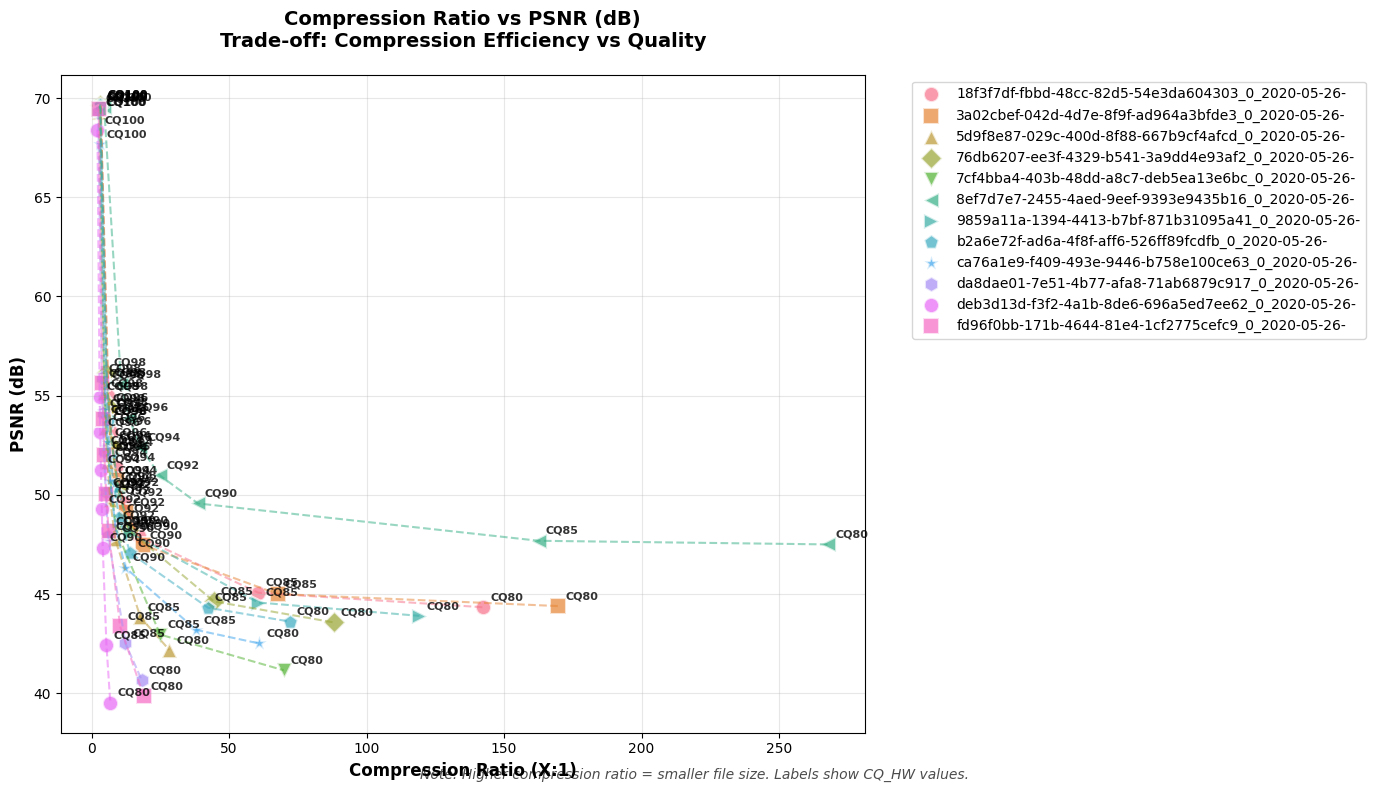


📈 Compression vs PSNR Analysis:
  18f3f7df-fbbd-48cc-82d5-54e3da604303_0_2020-05-26-:
    Best trade-off: CQ=80, PSNR=44.33dB, Ratio=142.4:1
    Max compression: 142.4:1 at PSNR=44.33dB
  3a02cbef-042d-4d7e-8f9f-ad964a3bfde3_0_2020-05-26-:
    Best trade-off: CQ=80, PSNR=44.39dB, Ratio=169.7:1
    Max compression: 169.7:1 at PSNR=44.39dB
  5d9f8e87-029c-400d-8f88-667b9cf4afcd_0_2020-05-26-:
    Best trade-off: CQ=80, PSNR=42.18dB, Ratio=28.2:1
    Max compression: 28.2:1 at PSNR=42.18dB
  76db6207-ee3f-4329-b541-3a9dd4e93af2_0_2020-05-26-:
    Best trade-off: CQ=80, PSNR=43.57dB, Ratio=88.1:1
    Max compression: 88.1:1 at PSNR=43.57dB
  7cf4bba4-403b-48dd-a8c7-deb5ea13e6bc_0_2020-05-26-:
    Best trade-off: CQ=80, PSNR=41.15dB, Ratio=69.9:1
    Max compression: 69.9:1 at PSNR=41.15dB
  8ef7d7e7-2455-4aed-9eef-9393e9435b16_0_2020-05-26-:
    Best trade-off: CQ=80, PSNR=47.50dB, Ratio=267.9:1
    Max compression: 267.9:1 at PSNR=47.50dB
  9859a11a-1394-4413-b7bf-871b31095a41_0_2020-05-

In [9]:
def plot_compression_vs_metric(df: pd.DataFrame, metric_col: str, metric_name: str,
                              title_suffix: str = "", figsize: tuple = (14, 8)):
    """
    Create a scatter/line plot of Compression Ratio vs a specified metric, grouped by experiment prefix.
    
    Args:
        df: DataFrame with experiment data
        metric_col: Column name for the y-axis metric
        metric_name: Display name for the metric
        title_suffix: Additional text for the title
        figsize: Figure size tuple
    """
    if df.empty:
        print(f"❌ No data available for compression ratio vs {metric_name} plot")
        return
    
    plt.figure(figsize=figsize)
    
    # Get unique experiment prefixes and create color palette
    prefixes = sorted(df['experiment_prefix'].unique())
    colors = sns.color_palette("husl", n_colors=len(prefixes))
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']  # Different markers for variety
    
    for i, prefix in enumerate(prefixes):
        prefix_data = df[df['experiment_prefix'] == prefix].sort_values('compression_ratio')
        
        if len(prefix_data) > 0:
            marker = markers[i % len(markers)]
            
            # Create both scatter and line plot for better visualization
            plt.scatter(prefix_data['compression_ratio'], prefix_data[metric_col], 
                       s=120, marker=marker, color=colors[i], alpha=0.7, 
                       edgecolors='white', linewidth=1.5, label=prefix)
            
            plt.plot(prefix_data['compression_ratio'], prefix_data[metric_col], 
                    color=colors[i], alpha=0.5, linewidth=1.5, linestyle='--')
            
            # Add data point labels
            for _, point in prefix_data.iterrows():
                plt.annotate(f'CQ{int(point["cq_hw"])}', 
                           (point['compression_ratio'], point[metric_col]),
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=8, alpha=0.8, fontweight='bold')
    
    plt.xlabel('Compression Ratio (X:1)', fontsize=12, fontweight='bold')
    plt.ylabel(f'{metric_name}', fontsize=12, fontweight='bold')
    plt.title(f'Compression Ratio vs {metric_name}{title_suffix}', fontsize=14, fontweight='bold', pad=20)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fancybox=True)
    plt.grid(True, alpha=0.3)
    
    # Add subtitle with explanation
    plt.figtext(0.5, 0.02, 
               'Note: Higher compression ratio = smaller file size. Labels show CQ_HW values.',
               ha='center', fontsize=10, style='italic', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Plot Compression Ratio vs PSNR
if not df_plot.empty and 'compression_ratio' in df_plot.columns and 'psnr' in df_plot.columns:
    print("📊 Creating Compression Ratio vs PSNR plot...")
    plot_compression_vs_metric(df_plot, 'psnr', 'PSNR (dB)', 
                              title_suffix='\nTrade-off: Compression Efficiency vs Quality')
    
    # Additional analysis
    print(f"\n📈 Compression vs PSNR Analysis:")
    for prefix in df_plot['experiment_prefix'].unique():
        prefix_data = df_plot[df_plot['experiment_prefix'] == prefix]
        
        # Find best trade-off point (highest PSNR * compression_ratio product)
        prefix_data = prefix_data.copy()
        prefix_data['quality_compression_score'] = prefix_data['psnr'] * np.log(prefix_data['compression_ratio'])
        best_tradeoff = prefix_data.loc[prefix_data['quality_compression_score'].idxmax()]
        
        print(f"  {prefix}:")
        print(f"    Best trade-off: CQ={int(best_tradeoff['cq_hw'])}, PSNR={best_tradeoff['psnr']:.2f}dB, Ratio={best_tradeoff['compression_ratio']:.1f}:1")
        print(f"    Max compression: {prefix_data['compression_ratio'].max():.1f}:1 at PSNR={prefix_data.loc[prefix_data['compression_ratio'].idxmax(), 'psnr']:.2f}dB")
        
else:
    print("❌ Cannot create Compression Ratio vs PSNR plot - missing data")

## Plot CQ_HW vs SSIM

Create line plots showing the relationship between CQ_HW values and SSIM metrics, with separate lines for each experiment group.

📊 Creating CQ_HW vs SSIM plot...


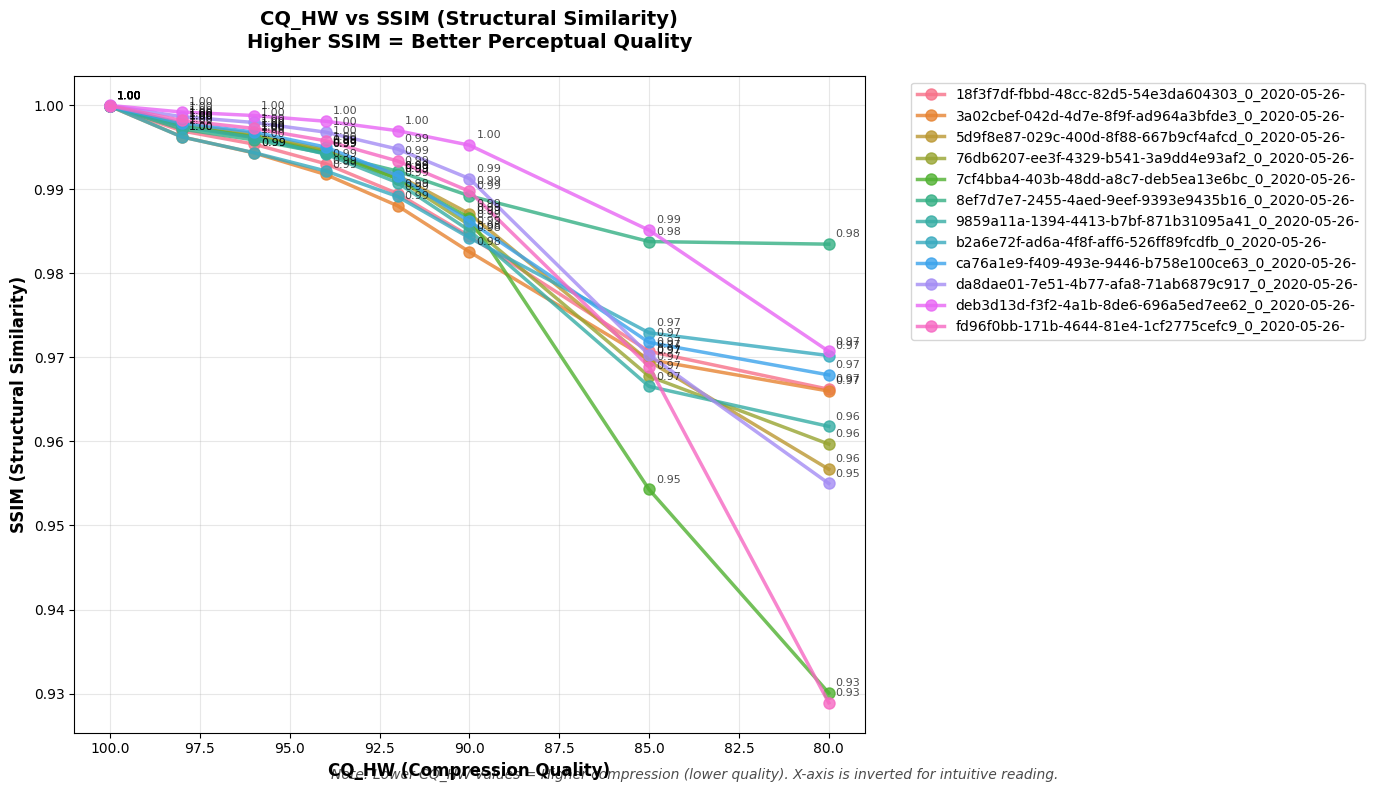


📈 SSIM Analysis:
  18f3f7df-fbbd-48cc-82d5-54e3da604303_0_2020-05-26-: SSIM range = 0.0337 (from 0.9662 to 0.9999)
    Maintains SSIM ≥ 0.95 down to CQ = 80
  3a02cbef-042d-4d7e-8f9f-ad964a3bfde3_0_2020-05-26-: SSIM range = 0.0339 (from 0.9660 to 0.9999)
    Maintains SSIM ≥ 0.95 down to CQ = 80
  5d9f8e87-029c-400d-8f88-667b9cf4afcd_0_2020-05-26-: SSIM range = 0.0432 (from 0.9567 to 0.9999)
    Maintains SSIM ≥ 0.95 down to CQ = 80
  76db6207-ee3f-4329-b541-3a9dd4e93af2_0_2020-05-26-: SSIM range = 0.0402 (from 0.9597 to 0.9999)
    Maintains SSIM ≥ 0.95 down to CQ = 80
  7cf4bba4-403b-48dd-a8c7-deb5ea13e6bc_0_2020-05-26-: SSIM range = 0.0698 (from 0.9301 to 0.9999)
    Maintains SSIM ≥ 0.95 down to CQ = 85
  8ef7d7e7-2455-4aed-9eef-9393e9435b16_0_2020-05-26-: SSIM range = 0.0164 (from 0.9835 to 0.9998)
    Maintains SSIM ≥ 0.95 down to CQ = 80
  9859a11a-1394-4413-b7bf-871b31095a41_0_2020-05-26-: SSIM range = 0.0381 (from 0.9618 to 0.9999)
    Maintains SSIM ≥ 0.95 down to CQ = 80
  

In [10]:
# Plot CQ_HW vs SSIM
if not df_plot.empty and 'ssim' in df_plot.columns:
    print("📊 Creating CQ_HW vs SSIM plot...")
    plot_cq_vs_metric(df_plot, 'ssim', 'SSIM (Structural Similarity)', 
                     title_suffix='\nHigher SSIM = Better Perceptual Quality')
    
    # Additional analysis
    print(f"\n📈 SSIM Analysis:")
    for prefix in df_plot['experiment_prefix'].unique():
        prefix_data = df_plot[df_plot['experiment_prefix'] == prefix]
        ssim_range = prefix_data['ssim'].max() - prefix_data['ssim'].min()
        print(f"  {prefix}: SSIM range = {ssim_range:.4f} (from {prefix_data['ssim'].min():.4f} to {prefix_data['ssim'].max():.4f})")
        
        # Find the CQ value where SSIM drops below 0.95 (good quality threshold)
        high_quality = prefix_data[prefix_data['ssim'] >= 0.95]
        if len(high_quality) > 0:
            min_cq_high_quality = high_quality['cq_hw'].min()
            print(f"    Maintains SSIM ≥ 0.95 down to CQ = {int(min_cq_high_quality)}")
        else:
            print(f"    No experiments with SSIM ≥ 0.95")
            
else:
    print("❌ Cannot create SSIM plot - missing data")

## Plot Compression Ratio vs SSIM

Generate scatter/line plots displaying compression ratio versus SSIM, grouped by experiment prefix with different colors/markers.

📊 Creating Compression Ratio vs SSIM plot...


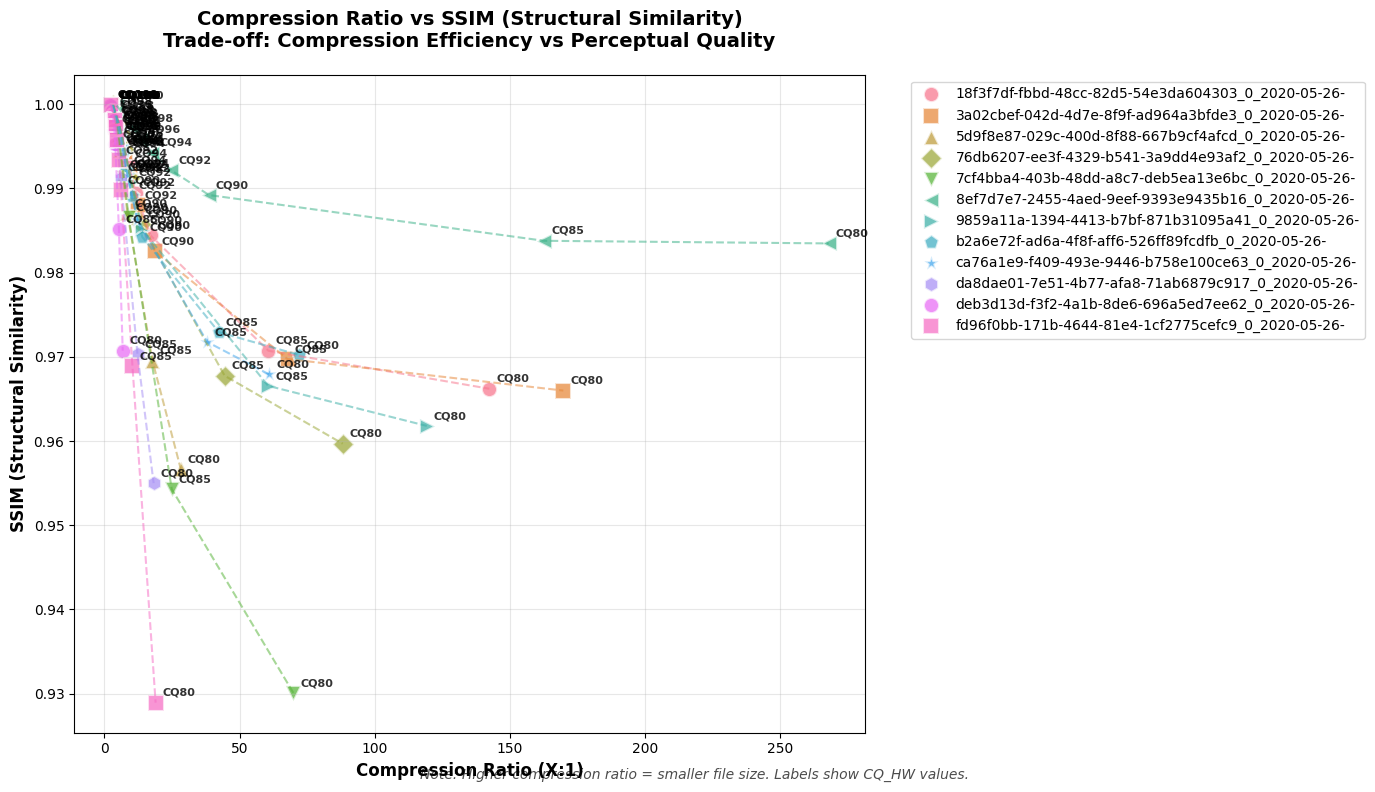


📈 Compression vs SSIM Analysis:
  18f3f7df-fbbd-48cc-82d5-54e3da604303_0_2020-05-26-:
    Best trade-off: CQ=80, SSIM=0.9662, Ratio=142.4:1
    Best compression with SSIM≥0.95: 142.4:1 at CQ=80
  3a02cbef-042d-4d7e-8f9f-ad964a3bfde3_0_2020-05-26-:
    Best trade-off: CQ=80, SSIM=0.9660, Ratio=169.7:1
    Best compression with SSIM≥0.95: 169.7:1 at CQ=80
  5d9f8e87-029c-400d-8f88-667b9cf4afcd_0_2020-05-26-:
    Best trade-off: CQ=80, SSIM=0.9567, Ratio=28.2:1
    Best compression with SSIM≥0.95: 28.2:1 at CQ=80
  76db6207-ee3f-4329-b541-3a9dd4e93af2_0_2020-05-26-:
    Best trade-off: CQ=80, SSIM=0.9597, Ratio=88.1:1
    Best compression with SSIM≥0.95: 88.1:1 at CQ=80
  7cf4bba4-403b-48dd-a8c7-deb5ea13e6bc_0_2020-05-26-:
    Best trade-off: CQ=80, SSIM=0.9301, Ratio=69.9:1
    Best compression with SSIM≥0.95: 24.9:1 at CQ=85
  8ef7d7e7-2455-4aed-9eef-9393e9435b16_0_2020-05-26-:
    Best trade-off: CQ=80, SSIM=0.9835, Ratio=267.9:1
    Best compression with SSIM≥0.95: 267.9:1 at CQ=80
 

In [19]:
# Plot Compression Ratio vs SSIM
if not df_plot.empty and 'compression_ratio' in df_plot.columns and 'ssim' in df_plot.columns:
    print("📊 Creating Compression Ratio vs SSIM plot...")
    plot_compression_vs_metric(df_plot, 'ssim', 'SSIM (Structural Similarity)', 
                              title_suffix='\nTrade-off: Compression Efficiency vs Perceptual Quality')
    
    # Additional analysis
    print(f"\n📈 Compression vs SSIM Analysis:")
    for prefix in df_plot['experiment_prefix'].unique():
        prefix_data = df_plot[df_plot['experiment_prefix'] == prefix]
        
        # Find best trade-off point for SSIM
        prefix_data = prefix_data.copy()
        prefix_data['ssim_compression_score'] = prefix_data['ssim'] * np.log(prefix_data['compression_ratio'])
        best_tradeoff = prefix_data.loc[prefix_data['ssim_compression_score'].idxmax()]
        
        print(f"  {prefix}:")
        print(f"    Best trade-off: CQ={int(best_tradeoff['cq_hw'])}, SSIM={best_tradeoff['ssim']:.4f}, Ratio={best_tradeoff['compression_ratio']:.1f}:1")
        
        # Find highest compression while maintaining good SSIM (>= 0.95)
        high_ssim = prefix_data[prefix_data['ssim'] >= 0.95]
        if len(high_ssim) > 0:
            best_compression_good_ssim = high_ssim.loc[high_ssim['compression_ratio'].idxmax()]
            print(f"    Best compression with SSIM≥0.95: {best_compression_good_ssim['compression_ratio']:.1f}:1 at CQ={int(best_compression_good_ssim['cq_hw'])}")
        else:
            print(f"    No experiments with SSIM ≥ 0.95")
            
else:
    print("❌ Cannot create Compression Ratio vs SSIM plot - missing data")

📊 Creating binned Compression Ratio vs SSIM plot (0-40 range)...
📊 Using 82 data points in the 0-40 compression ratio range
   Combining data from 12 experiment groups:
     - 18f3f7df-fbbd-48cc-82d5-54e3da604303_0_2020-05-26-: 6 points
     - 3a02cbef-042d-4d7e-8f9f-ad964a3bfde3_0_2020-05-26-: 6 points
     - 5d9f8e87-029c-400d-8f88-667b9cf4afcd_0_2020-05-26-: 8 points
     - 76db6207-ee3f-4329-b541-3a9dd4e93af2_0_2020-05-26-: 6 points
     - 7cf4bba4-403b-48dd-a8c7-deb5ea13e6bc_0_2020-05-26-: 7 points
     - 8ef7d7e7-2455-4aed-9eef-9393e9435b16_0_2020-05-26-: 6 points
     - 9859a11a-1394-4413-b7bf-871b31095a41_0_2020-05-26-: 6 points
     - b2a6e72f-ad6a-4f8f-aff6-526ff89fcdfb_0_2020-05-26-: 6 points
     - ca76a1e9-f409-493e-9446-b758e100ce63_0_2020-05-26-: 7 points
     - da8dae01-7e51-4b77-afa8-71ab6879c917_0_2020-05-26-: 8 points
     - deb3d13d-f3f2-4a1b-8de6-696a5ed7ee62_0_2020-05-26-: 8 points
     - fd96f0bb-171b-4644-81e4-1cf2775cefc9_0_2020-05-26-: 8 points


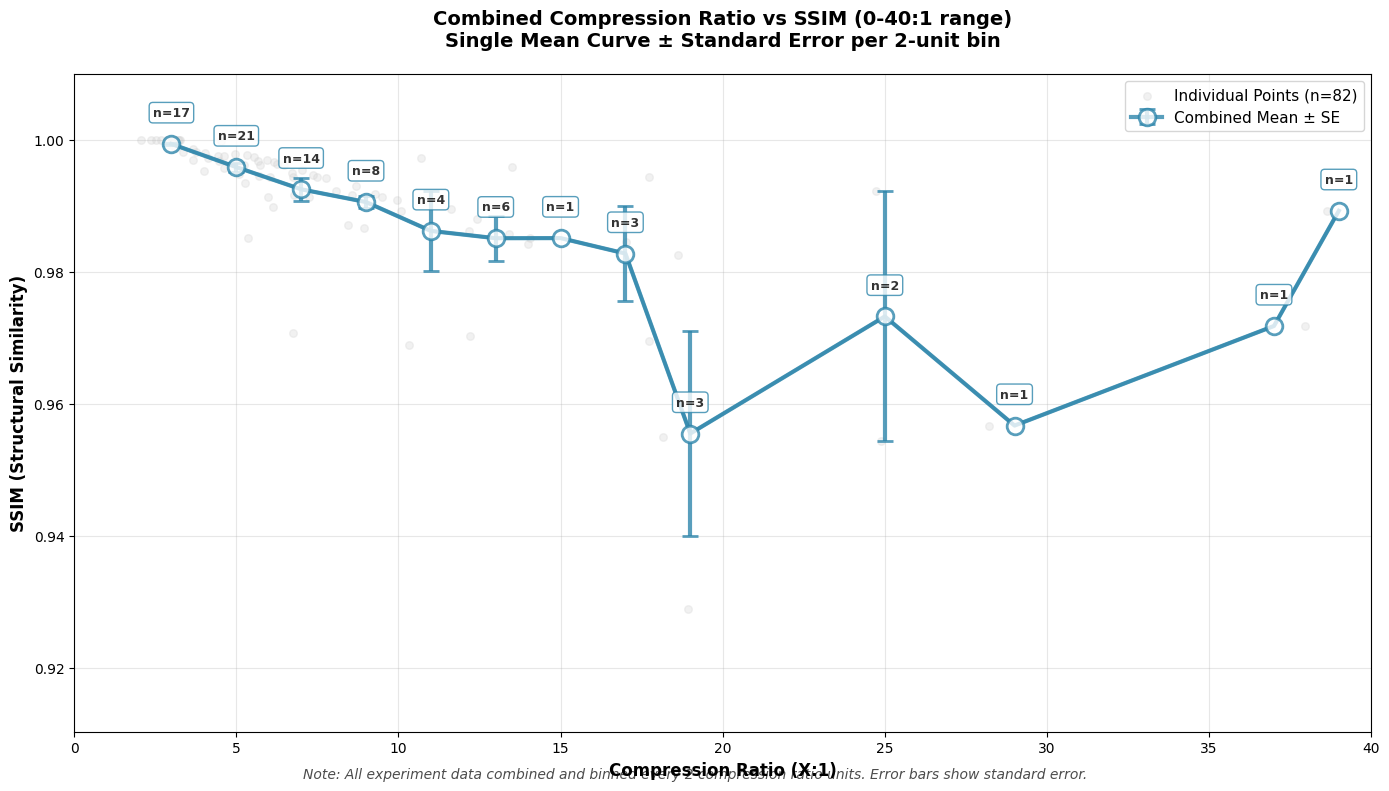


📈 Combined Binning Statistics:
  Bin size: 2 compression ratio units
  Total bins with data: 13
  Total data points used: 82

📊 Bin Details:
  Bin 2.0-4.0: Mean SSIM = 0.9993 ± 0.0002, n = 17
  Bin 4.0-6.0: Mean SSIM = 0.9958 ± 0.0007, n = 21
  Bin 6.0-8.0: Mean SSIM = 0.9925 ± 0.0018, n = 14
  Bin 8.0-10.0: Mean SSIM = 0.9905 ± 0.0008, n = 8
  Bin 10.0-12.0: Mean SSIM = 0.9862 ± 0.0060, n = 4
  Bin 12.0-14.0: Mean SSIM = 0.9851 ± 0.0034, n = 6
  Bin 14.0-16.0: Mean SSIM = 0.9851 ± nan, n = 1
  Bin 16.0-18.0: Mean SSIM = 0.9827 ± 0.0072, n = 3
  Bin 18.0-20.0: Mean SSIM = 0.9555 ± 0.0155, n = 3
  Bin 24.0-26.0: Mean SSIM = 0.9732 ± 0.0189, n = 2
  Bin 28.0-30.0: Mean SSIM = 0.9567 ± nan, n = 1
  Bin 36.0-38.0: Mean SSIM = 0.9718 ± nan, n = 1
  Bin 38.0-40.0: Mean SSIM = 0.9892 ± nan, n = 1

🎯 Key Findings:
  Best quality bin: 2.0-4.0 (SSIM = 0.9993)
  Best trade-off (SSIM≥0.95): 38.0-40.0 (SSIM = 0.9892)

📈 Combined Analysis (0-40 range):
  Total data points: 82
  SSIM range: 0.9289 -

In [20]:
def plot_binned_compression_vs_ssim(df: pd.DataFrame, max_ratio: float = 40, bin_size: float = 2):
    """
    Create a single binned plot of Compression Ratio vs SSIM with mean and standard error across all runs.
    
    Args:
        df: DataFrame with experiment data
        max_ratio: Maximum compression ratio to include
        bin_size: Size of each bin for compression ratio
    """
    if df.empty:
        print("❌ No data available for binned compression vs SSIM plot")
        return
    
    # Filter data to the specified range
    df_filtered = df[(df['compression_ratio'] >= 0) & (df['compression_ratio'] <= max_ratio)].copy()
    
    if len(df_filtered) == 0:
        print(f"❌ No data points in the 0-{max_ratio} compression ratio range")
        return
    
    print(f"📊 Using {len(df_filtered)} data points in the 0-{max_ratio} compression ratio range")
    print(f"   Combining data from {df_filtered['experiment_prefix'].nunique()} experiment groups:")
    for prefix in sorted(df_filtered['experiment_prefix'].unique()):
        count = len(df_filtered[df_filtered['experiment_prefix'] == prefix])
        print(f"     - {prefix}: {count} points")
    
    plt.figure(figsize=(14, 8))
    
    # Create bins for all data combined
    bin_edges = np.arange(0, max_ratio + bin_size, bin_size)
    bin_centers = bin_edges[:-1] + bin_size / 2
    
    # Bin all the data together
    binned_means = []
    binned_stds = []
    binned_centers = []
    bin_counts = []
    
    for j in range(len(bin_edges) - 1):
        bin_mask = ((df_filtered['compression_ratio'] >= bin_edges[j]) & 
                   (df_filtered['compression_ratio'] < bin_edges[j + 1]))
        bin_data = df_filtered[bin_mask]['ssim']
        
        if len(bin_data) > 0:
            binned_means.append(bin_data.mean())
            binned_stds.append(bin_data.std() / np.sqrt(len(bin_data)))  # Standard error
            binned_centers.append(bin_centers[j])
            bin_counts.append(len(bin_data))
    
    if len(binned_means) > 0:
        binned_means = np.array(binned_means)
        binned_stds = np.array(binned_stds)
        binned_centers = np.array(binned_centers)
        
        # Plot single mean curve with error bars
        plt.errorbar(binned_centers, binned_means, yerr=binned_stds,
                    marker='o', markersize=12, linewidth=3, capsize=6,
                    label='Combined Mean ± SE', color='#2E86AB', alpha=0.8,
                    markerfacecolor='white', markeredgewidth=2)
        
        # Connect points with line
        plt.plot(binned_centers, binned_means, color='#2E86AB', alpha=0.7, 
                linewidth=2.5, linestyle='-')
        
        # Add data count annotations
        for center, mean_val, count in zip(binned_centers, binned_means, bin_counts):
            plt.annotate(f'n={count}', (center, mean_val),
                       xytext=(0, 20), textcoords='offset points',
                       ha='center', fontsize=9, alpha=0.8, fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                               edgecolor='#2E86AB', alpha=0.8, linewidth=1))
        
        # Optionally, show individual data points as scatter plot
        plt.scatter(df_filtered['compression_ratio'], df_filtered['ssim'], 
                   alpha=0.3, s=30, color='lightgray', 
                   label=f'Individual Points (n={len(df_filtered)})')
    
    plt.xlabel('Compression Ratio (X:1)', fontsize=12, fontweight='bold')
    plt.ylabel('SSIM (Structural Similarity)', fontsize=12, fontweight='bold')
    plt.title(f'Combined Compression Ratio vs SSIM (0-{max_ratio}:1 range)\nSingle Mean Curve ± Standard Error per {bin_size}-unit bin', 
              fontsize=14, fontweight='bold', pad=20)
    plt.legend(frameon=True, fancybox=True, fontsize=11)
    plt.grid(True, alpha=0.3)
    
    # Set axis limits
    plt.xlim(0, max_ratio)
    plt.ylim(df_filtered['ssim'].min() * 0.98, df_filtered['ssim'].max() * 1.01)
    
    # Add subtitle with explanation
    plt.figtext(0.5, 0.02, 
               f'Note: All experiment data combined and binned every {bin_size} compression ratio units. Error bars show standard error.',
               ha='center', fontsize=10, style='italic', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed binning statistics
    print(f"\n📈 Combined Binning Statistics:")
    print(f"  Bin size: {bin_size} compression ratio units")
    print(f"  Total bins with data: {len([c for c in bin_counts if c > 0])}")
    print(f"  Total data points used: {sum(bin_counts)}")
    
    print(f"\n📊 Bin Details:")
    for i, (center, mean_val, std_err, count) in enumerate(zip(binned_centers, binned_means, binned_stds, bin_counts)):
        print(f"  Bin {center-bin_size/2:.1f}-{center+bin_size/2:.1f}: "
              f"Mean SSIM = {mean_val:.4f} ± {std_err:.4f}, n = {count}")
    
    # Find optimal compression ratio range
    if len(binned_means) > 0:
        # Find bin with highest SSIM
        best_quality_idx = np.argmax(binned_means)
        print(f"\n🎯 Key Findings:")
        print(f"  Best quality bin: {binned_centers[best_quality_idx]-bin_size/2:.1f}-{binned_centers[best_quality_idx]+bin_size/2:.1f} "
              f"(SSIM = {binned_means[best_quality_idx]:.4f})")
        
        # Find good trade-off (SSIM >= 0.95 with highest compression)
        good_quality_bins = binned_means >= 0.95
        if np.any(good_quality_bins):
            good_compressions = binned_centers[good_quality_bins]
            best_tradeoff_ratio = np.max(good_compressions)
            best_tradeoff_idx = np.where(binned_centers == best_tradeoff_ratio)[0][0]
            print(f"  Best trade-off (SSIM≥0.95): {best_tradeoff_ratio-bin_size/2:.1f}-{best_tradeoff_ratio+bin_size/2:.1f} "
                  f"(SSIM = {binned_means[best_tradeoff_idx]:.4f})")
        else:
            print(f"  No bins achieve SSIM ≥ 0.95")

# Plot Compression Ratio vs SSIM with binning
if not df_plot.empty and 'compression_ratio' in df_plot.columns and 'ssim' in df_plot.columns:
    print("📊 Creating binned Compression Ratio vs SSIM plot (0-40 range)...")
    plot_binned_compression_vs_ssim(df_plot, max_ratio=40, bin_size=2)
    
    # Additional analysis for the combined data
    df_filtered = df_plot[(df_plot['compression_ratio'] >= 0) & (df_plot['compression_ratio'] <= 40)]
    
    if not df_filtered.empty:
        print(f"\n📈 Combined Analysis (0-40 range):")
        print(f"  Total data points: {len(df_filtered)}")
        print(f"  SSIM range: {df_filtered['ssim'].min():.4f} - {df_filtered['ssim'].max():.4f}")
        print(f"  Compression range: {df_filtered['compression_ratio'].min():.1f} - {df_filtered['compression_ratio'].max():.1f}")
        
        # Find best overall trade-off point
        df_filtered_copy = df_filtered.copy()
        df_filtered_copy['ssim_compression_score'] = df_filtered_copy['ssim'] * np.log(df_filtered_copy['compression_ratio'] + 1)
        best_tradeoff = df_filtered_copy.loc[df_filtered_copy['ssim_compression_score'].idxmax()]
        
        print(f"  Best individual trade-off point: CQ={int(best_tradeoff['cq_hw'])}, "
              f"SSIM={best_tradeoff['ssim']:.4f}, Ratio={best_tradeoff['compression_ratio']:.1f}:1")
        print(f"  From experiment: {best_tradeoff['experiment_prefix']}")
        
        # Find highest compression while maintaining good SSIM (>= 0.95)
        high_ssim = df_filtered_copy[df_filtered_copy['ssim'] >= 0.95]
        if len(high_ssim) > 0:
            best_compression_good_ssim = high_ssim.loc[high_ssim['compression_ratio'].idxmax()]
            print(f"  Best compression with SSIM≥0.95: {best_compression_good_ssim['compression_ratio']:.1f}:1 "
                  f"at CQ={int(best_compression_good_ssim['cq_hw'])} ({best_compression_good_ssim['experiment_prefix']})")
        else:
            print(f"  No experiments with SSIM ≥ 0.95 in this range")
    
else:
    print("❌ Cannot create binned Compression Ratio vs SSIM plot - missing data")

## Summary and Recommendations

Analyze the results and provide recommendations for optimal compression settings.

In [12]:
def generate_summary_report(df: pd.DataFrame):
    """
    Generate a comprehensive summary report of the compression analysis.
    
    Args:
        df: DataFrame with experiment results
    """
    if df.empty:
        print("❌ No data available for summary report")
        return
    
    print("📋 TIFF COMPRESSION ANALYSIS SUMMARY REPORT")
    print("=" * 60)
    
    # Overall statistics
    print(f"\n📊 OVERALL STATISTICS:")
    print(f"  Total experiments analyzed: {len(df)}")
    print(f"  Experiment groups: {df['experiment_prefix'].nunique()}")
    print(f"  CQ_HW range tested: {int(df['cq_hw'].min())} - {int(df['cq_hw'].max())}")
    
    # Quality metrics ranges
    print(f"\n🎯 QUALITY METRICS RANGES:")
    print(f"  PSNR: {df['psnr'].min():.2f} - {df['psnr'].max():.2f} dB")
    print(f"  SSIM: {df['ssim'].min():.4f} - {df['ssim'].max():.4f}")
    print(f"  Compression Ratio: {df['compression_ratio'].min():.1f}:1 - {df['compression_ratio'].max():.1f}:1")
    
    # Best performing experiments
    print(f"\n🏆 BEST PERFORMING EXPERIMENTS:")
    
    # Highest PSNR
    best_psnr = df.loc[df['psnr'].idxmax()]
    print(f"  Highest PSNR: {best_psnr['psnr']:.2f}dB")
    print(f"    Experiment: {best_psnr['experiment_name']}")
    print(f"    Settings: CQ={int(best_psnr['cq_hw'])}, Ratio={best_psnr['compression_ratio']:.1f}:1, SSIM={best_psnr['ssim']:.4f}")
    
    # Highest SSIM
    best_ssim = df.loc[df['ssim'].idxmax()]
    print(f"  Highest SSIM: {best_ssim['ssim']:.4f}")
    print(f"    Experiment: {best_ssim['experiment_name']}")
    print(f"    Settings: CQ={int(best_ssim['cq_hw'])}, Ratio={best_ssim['compression_ratio']:.1f}:1, PSNR={best_ssim['psnr']:.2f}dB")
    
    # Best compression ratio
    best_compression = df.loc[df['compression_ratio'].idxmax()]
    print(f"  Highest Compression: {best_compression['compression_ratio']:.1f}:1")
    print(f"    Experiment: {best_compression['experiment_name']}")
    print(f"    Settings: CQ={int(best_compression['cq_hw'])}, PSNR={best_compression['psnr']:.2f}dB, SSIM={best_compression['ssim']:.4f}")
    
    # Recommendations by experiment group
    print(f"\n💡 RECOMMENDATIONS BY EXPERIMENT GROUP:")
    for prefix in sorted(df['experiment_prefix'].unique()):
        prefix_data = df[df['experiment_prefix'] == prefix]
        print(f"\n  📁 {prefix.upper()}:")
        
        # Sweet spot analysis (balance between quality and compression)
        prefix_data = prefix_data.copy()
        
        # Normalize metrics to 0-1 scale for scoring
        prefix_data['psnr_norm'] = (prefix_data['psnr'] - prefix_data['psnr'].min()) / (prefix_data['psnr'].max() - prefix_data['psnr'].min())
        prefix_data['ssim_norm'] = (prefix_data['ssim'] - prefix_data['ssim'].min()) / (prefix_data['ssim'].max() - prefix_data['ssim'].min())
        prefix_data['compression_norm'] = (prefix_data['compression_ratio'] - prefix_data['compression_ratio'].min()) / (prefix_data['compression_ratio'].max() - prefix_data['compression_ratio'].min())
        
        # Combined score (weighted: quality 60%, compression 40%)
        prefix_data['overall_score'] = (0.3 * prefix_data['psnr_norm'] + 
                                      0.3 * prefix_data['ssim_norm'] + 
                                      0.4 * prefix_data['compression_norm'])
        
        best_overall = prefix_data.loc[prefix_data['overall_score'].idxmax()]
        
        print(f"    🎯 Recommended setting: CQ = {int(best_overall['cq_hw'])}")
        print(f"       Quality: PSNR = {best_overall['psnr']:.2f}dB, SSIM = {best_overall['ssim']:.4f}")
        print(f"       Compression: {best_overall['compression_ratio']:.1f}:1 ratio, {best_overall['space_savings']:.1f}% space savings")
        
        # Conservative recommendation (prioritize quality)
        high_quality = prefix_data[prefix_data['ssim'] >= 0.98]  # Very high quality
        if len(high_quality) > 0:
            conservative = high_quality.loc[high_quality['compression_ratio'].idxmax()]
            print(f"    🛡️  Conservative (high quality): CQ = {int(conservative['cq_hw'])}")
            print(f"       Maintains SSIM ≥ 0.98 with {conservative['compression_ratio']:.1f}:1 compression")
        
        # Aggressive recommendation (prioritize compression)
        decent_quality = prefix_data[prefix_data['ssim'] >= 0.90]  # Acceptable quality
        if len(decent_quality) > 0:
            aggressive = decent_quality.loc[decent_quality['compression_ratio'].idxmax()]
            print(f"    ⚡ Aggressive (high compression): CQ = {int(aggressive['cq_hw'])}")
            print(f"       Achieves {aggressive['compression_ratio']:.1f}:1 compression with SSIM = {aggressive['ssim']:.4f}")

# Generate the summary report
if not df_plot.empty:
    generate_summary_report(df_plot)
else:
    print("❌ No data available for summary report")

print(f"\n" + "="*60)
print("🎉 Analysis complete! Use the plots above to make informed decisions about compression settings.")
print("💡 Consider running additional experiments with intermediate CQ values for fine-tuning.")

📋 TIFF COMPRESSION ANALYSIS SUMMARY REPORT

📊 OVERALL STATISTICS:
  Total experiments analyzed: 96
  Experiment groups: 12
  CQ_HW range tested: 80 - 100

🎯 QUALITY METRICS RANGES:
  PSNR: 39.52 - 69.67 dB
  SSIM: 0.9289 - 1.0000
  Compression Ratio: 2.1:1 - 267.9:1

🏆 BEST PERFORMING EXPERIMENTS:
  Highest PSNR: 69.67dB
    Experiment: 76db6207-ee3f-4329-b541-3a9dd4e93af2_0_2020-05-26-_cq100
    Settings: CQ=100, Ratio=3.1:1, SSIM=0.9999
  Highest SSIM: 1.0000
    Experiment: deb3d13d-f3f2-4a1b-8de6-696a5ed7ee62_0_2020-05-26-_cq100
    Settings: CQ=100, Ratio=2.1:1, PSNR=68.39dB
  Highest Compression: 267.9:1
    Experiment: 8ef7d7e7-2455-4aed-9eef-9393e9435b16_0_2020-05-26-_cq80
    Settings: CQ=80, PSNR=47.50dB, SSIM=0.9835

💡 RECOMMENDATIONS BY EXPERIMENT GROUP:

  📁 18F3F7DF-FBBD-48CC-82D5-54E3DA604303_0_2020-05-26-:
    🎯 Recommended setting: CQ = 100
       Quality: PSNR = 69.59dB, SSIM = 0.9999
       Compression: 3.2:1 ratio, 69.1% space savings
    🛡️  Conservative (high qual

## Export Results

Save the processed data to CSV files for further analysis or reporting.

In [13]:
import os
from datetime import datetime

def export_results(df: pd.DataFrame, base_path: str = "../scripts/compression_analysis_output"):
    """
    Export the analysis results to CSV files.
    
    Args:
        df: DataFrame with processed results
        base_path: Base directory for output files
    """
    if df.empty:
        print("❌ No data to export")
        return
    
    # Create output directory if it doesn't exist
    output_dir = os.path.join(base_path, "analysis_exports")
    os.makedirs(output_dir, exist_ok=True)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Export complete results
    complete_file = os.path.join(output_dir, f"compression_results_complete_{timestamp}.csv")
    df.to_csv(complete_file, index=False)
    print(f"✅ Complete results exported to: {complete_file}")
    
    # Export summary by experiment prefix
    summary_data = []
    for prefix in df['experiment_prefix'].unique():
        prefix_data = df[df['experiment_prefix'] == prefix]
        
        summary_data.append({
            'experiment_prefix': prefix,
            'num_experiments': len(prefix_data),
            'cq_values_tested': ', '.join(map(str, sorted(prefix_data['cq_hw'].unique()))),
            'psnr_range': f"{prefix_data['psnr'].min():.2f} - {prefix_data['psnr'].max():.2f}",
            'ssim_range': f"{prefix_data['ssim'].min():.4f} - {prefix_data['ssim'].max():.4f}",
            'compression_range': f"{prefix_data['compression_ratio'].min():.1f} - {prefix_data['compression_ratio'].max():.1f}",
            'best_cq_for_quality': int(prefix_data.loc[prefix_data['ssim'].idxmax(), 'cq_hw']),
            'best_cq_for_compression': int(prefix_data.loc[prefix_data['compression_ratio'].idxmax(), 'cq_hw']),
            'avg_psnr': prefix_data['psnr'].mean(),
            'avg_ssim': prefix_data['ssim'].mean(),
            'avg_compression_ratio': prefix_data['compression_ratio'].mean()
        })
    
    summary_df = pd.DataFrame(summary_data)
    summary_file = os.path.join(output_dir, f"compression_summary_{timestamp}.csv")
    summary_df.to_csv(summary_file, index=False)
    print(f"✅ Summary by prefix exported to: {summary_file}")
    
    return complete_file, summary_file

# Export results if data is available
if not df_plot.empty:
    print("💾 Exporting results...")
    try:
        complete_file, summary_file = export_results(df_plot)
        print(f"\n📁 Files exported successfully!")
        print(f"  Complete data: {os.path.basename(complete_file)}")
        print(f"  Summary data: {os.path.basename(summary_file)}")
    except Exception as e:
        print(f"❌ Error exporting files: {e}")
else:
    print("⚠️  No data to export")

print(f"\n🎯 Next steps:")
print("1. Review the plots to understand quality vs compression trade-offs")
print("2. Use the recommendations to select optimal CQ_HW values")
print("3. Run additional experiments with fine-tuned parameters if needed")
print("4. Check the exported CSV files for detailed numerical analysis")

💾 Exporting results...
✅ Complete results exported to: ../scripts/compression_analysis_output/analysis_exports/compression_results_complete_20250911_084850.csv
✅ Summary by prefix exported to: ../scripts/compression_analysis_output/analysis_exports/compression_summary_20250911_084850.csv

📁 Files exported successfully!
  Complete data: compression_results_complete_20250911_084850.csv
  Summary data: compression_summary_20250911_084850.csv

🎯 Next steps:
1. Review the plots to understand quality vs compression trade-offs
2. Use the recommendations to select optimal CQ_HW values
3. Run additional experiments with fine-tuned parameters if needed
4. Check the exported CSV files for detailed numerical analysis
